# 🚁 NOTEBOOK 02: DATA VISUALIZATION & VALIDATION
**Project:** Intelligent Drone Flight Maneuver Recognition  
**Phase:** Validation (QC)  
**Role:** Data Scientist

## 🎯 Mục tiêu
1. **Load:** Đọc dữ liệu sạch (`train_raw_clean.csv`) từ Bước 1.
2. **Inspect:** Kiểm tra phân bố số lượng mẫu (Đã đủ 30 lần cho mỗi hành động chưa?).
3. **Visualize by Class:** Vẽ biểu đồ tín hiệu của từng hành động để kiểm tra độ nhất quán (Consistency).
   - *Kỳ vọng:* 30 lần thực hiện `Move_Left` phải có hình dạng sóng na ná nhau.
4. **Validate Physics:** Kiểm tra xem chiến thuật "Tilt & Hold" có tạo ra các đường Plateau (Cao nguyên) trên đồ thị hay không.

In [1]:
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

drive.mount('/content/drive')

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams['figure.figsize'] = (14, 6)

# --- CONFIG ---
BASE_DIR = Path('/content/drive/MyDrive/Drone_Project_2025')
INTERIM_DATA_DIR = BASE_DIR / 'data/interim'
INPUT_FILE = INTERIM_DATA_DIR / 'train_raw_clean.csv'

Mounted at /content/drive


## 📥 1. LOAD & INSPECT DATA

In [2]:
if not INPUT_FILE.exists():
    print("❌ Lỗi: Không tìm thấy file dữ liệu. Hãy chạy Notebook 01 trước!")
else:
    df = pd.read_csv(INPUT_FILE)
    print(f"✅ Đã load dữ liệu: {len(df)} dòng.")

    # Kiểm tra số lượng mẫu (segments) cho mỗi nhãn
    # Lưu ý: Mỗi lần nhấn nút là 1 segment_id riêng biệt
    segment_counts = df.groupby('label')['segment_id'].nunique()
    print("\n📊 Số lần thực hiện (Events) cho mỗi hành động:")
    print(segment_counts)

✅ Đã load dữ liệu: 52362 dòng.

📊 Số lần thực hiện (Events) cho mỗi hành động:
label
HOVER             1
IDLE              1
LANDING          30
MOVE_BACKWARD    36
MOVE_FORWARD     34
MOVE_LEFT        30
MOVE_RIGHT       29
TAKEOFF          30
TURBULENCE        1
Name: segment_id, dtype: int64


## 📈 2. VISUALIZATION: SIGNAL SIGNATURE (CHỮ KÝ TÍN HIỆU)
Chúng ta sẽ vẽ 3 mẫu ngẫu nhiên cho mỗi Class để xem sự tương đồng.

In [3]:
def plot_class_signature(df, label_name, axes=['acc_x', 'acc_y', 'acc_z'], n_samples=3):
    """
    Vẽ n_samples ngẫu nhiên của một nhãn cụ thể để kiểm tra độ ổn định thao tác.
    """
    subset = df[df['label'] == label_name]
    unique_segments = subset['segment_id'].unique()

    if len(unique_segments) == 0:
        print(f"⚠️ Không có dữ liệu cho nhãn {label_name}")
        return

    # Chọn ngẫu nhiên (hoặc lấy đầu tiên) các segment
    selected_segs = unique_segments[:n_samples]

    fig, axs = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
    fig.suptitle(f"SIGNAL SIGNATURE: {label_name} (Top {n_samples} samples)", fontsize=16, fontweight='bold')

    for i, seg_id in enumerate(selected_segs):
        seg_data = subset[subset['segment_id'] == seg_id].reset_index(drop=True)

        # Vẽ 3 trục Accel
        axs[i].plot(seg_data['acc_x'], label='Acc X (Roll)', color='orange', alpha=0.8)
        axs[i].plot(seg_data['acc_y'], label='Acc Y (Pitch)', color='green', alpha=0.8)
        axs[i].plot(seg_data['acc_z'], label='Acc Z (Vertical)', color='blue', alpha=0.8)

        axs[i].set_title(f"Event #{i+1} (Duration: {len(seg_data)/100:.1f}s)")
        axs[i].set_xlabel("Samples (100Hz)")
        if i == 0: axs[i].set_ylabel("Acceleration (m/s²)")
        axs[i].grid(True, linestyle='--', alpha=0.5)

    # Legend chung
    handles, labels = axs[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper right')
    plt.tight_layout()
    plt.show()

### 🔍 KIỂM TRA NHÓM TRỤC DỌC (VERTICAL)
**Kỳ vọng:**
- **TAKEOFF:** `Acc_Z` phải có đỉnh dương rất cao (>15) hoặc kéo dài trên 10.
- **LANDING:** `Acc_Z` phải tụt sâu xuống (<5) hoặc âm.

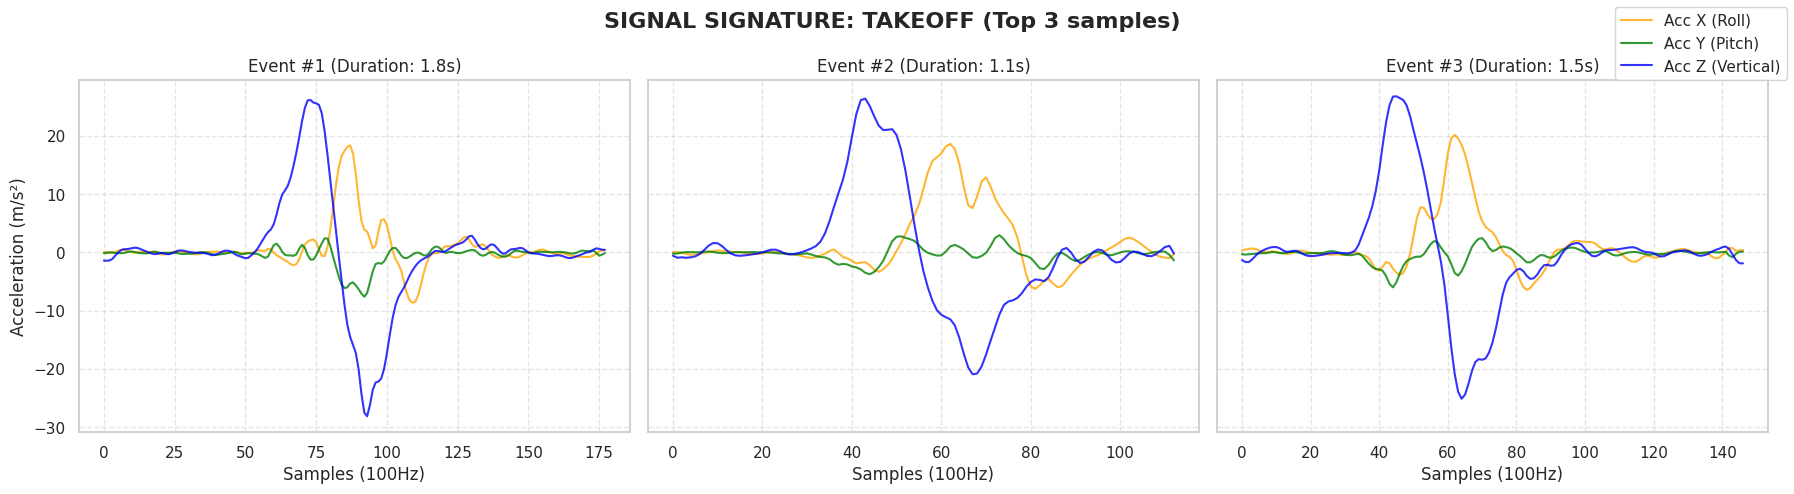

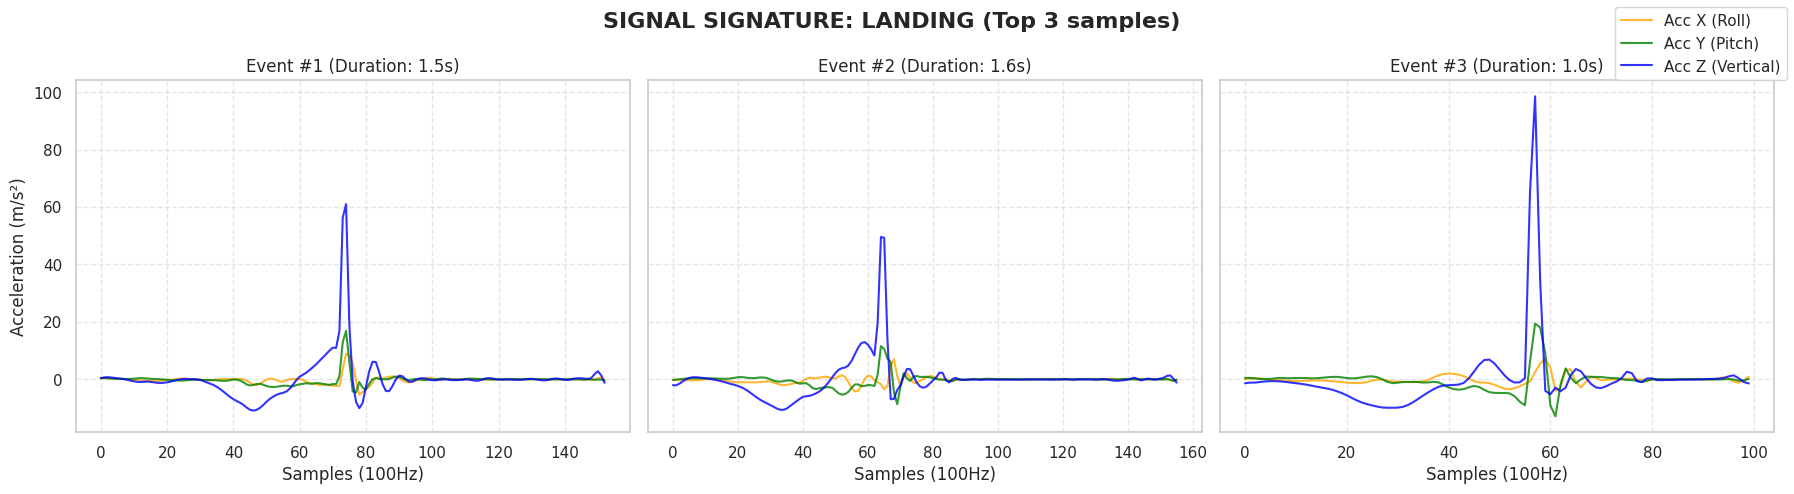

In [4]:
plot_class_signature(df, 'TAKEOFF', n_samples=3)
plot_class_signature(df, 'LANDING', n_samples=3)

### 🔍 KIỂM TRA NHÓM NGHIÊNG TRÁI/PHẢI (ROLL)
**Chiến thuật "Nghiêng & Giữ":**
- **MOVE_LEFT:** `Acc_X` (màu cam) phải tách ra khỏi 0 và giữ ở mức dương/âm (tùy chiều thiết bị) trong suốt đoạn giữa.
- **MOVE_RIGHT:** `Acc_X` phải đi ngược chiều so với Left.

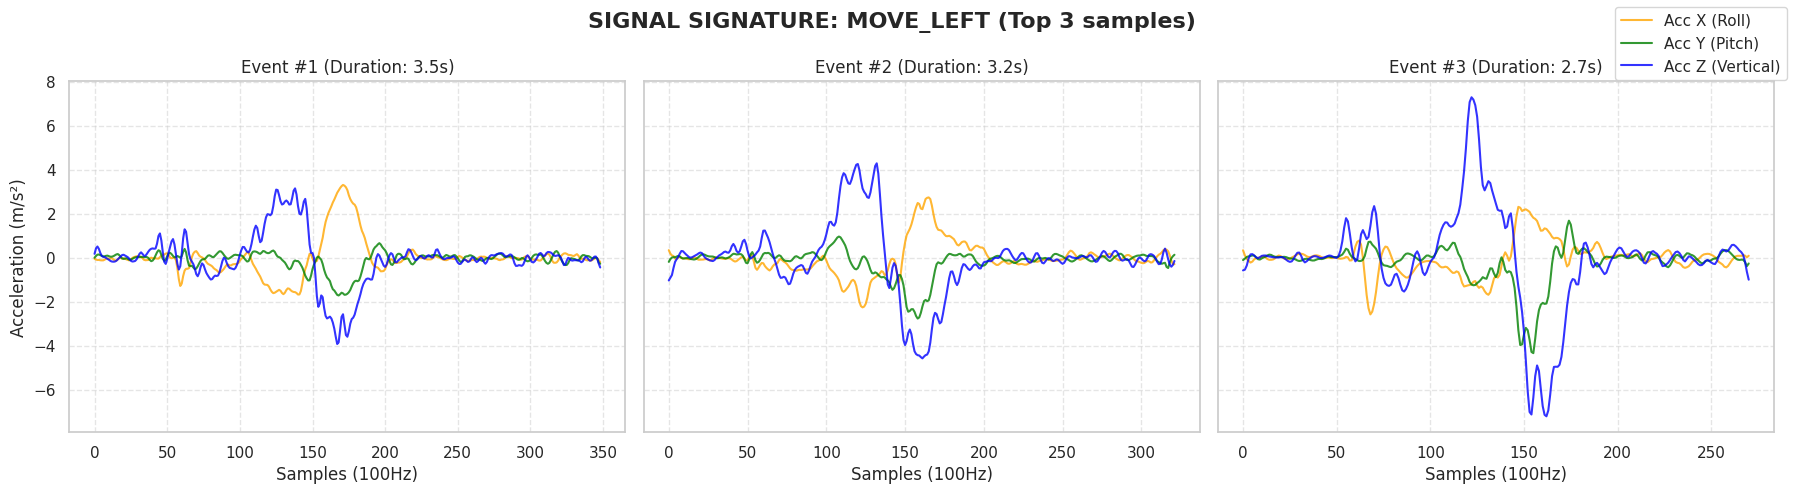

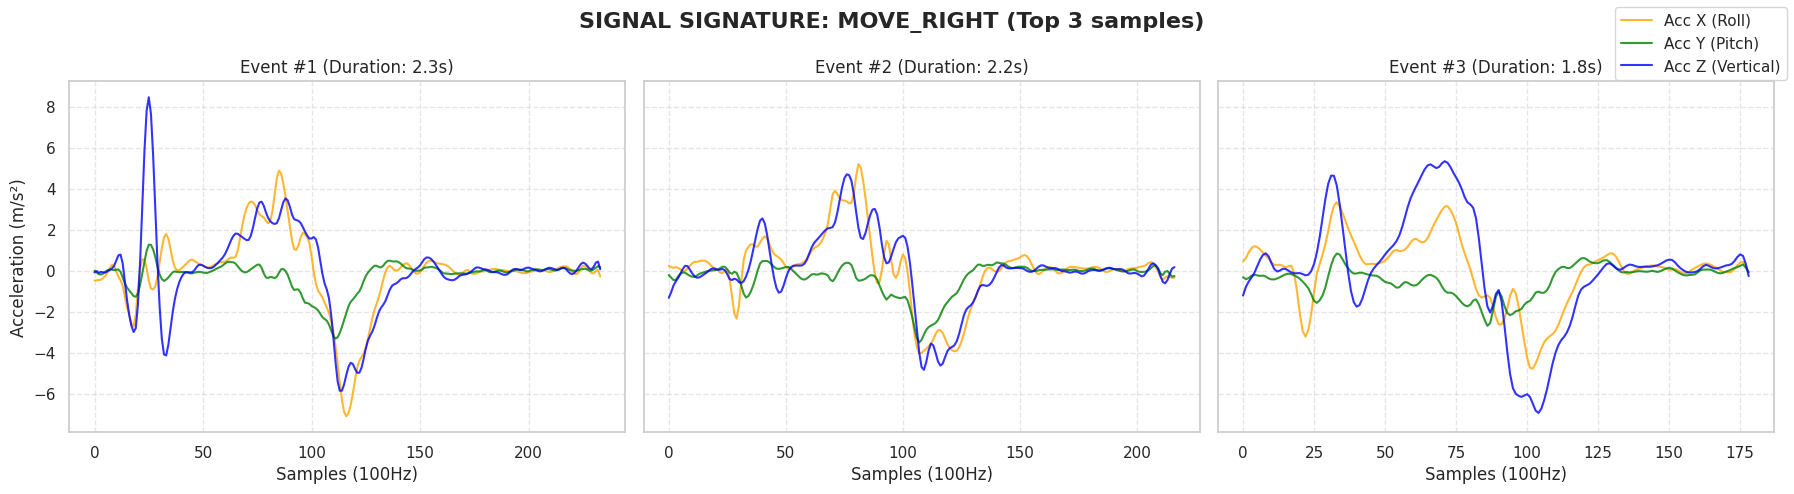

In [5]:
plot_class_signature(df, 'MOVE_LEFT', n_samples=3)
plot_class_signature(df, 'MOVE_RIGHT', n_samples=3)

### 🔍 KIỂM TRA NHÓM CHÚI/NGỬA (PITCH)
**Chiến thuật "Nghiêng & Giữ":**
- **MOVE_FORWARD (Chúi):** Quan sát `Acc_Y` (màu xanh lá) hoặc `Acc_Z` thay đổi mức nền (Offset).
- **MOVE_BACKWARD (Ngửa):** `Acc_Y` sẽ đi ngược chiều Forward.

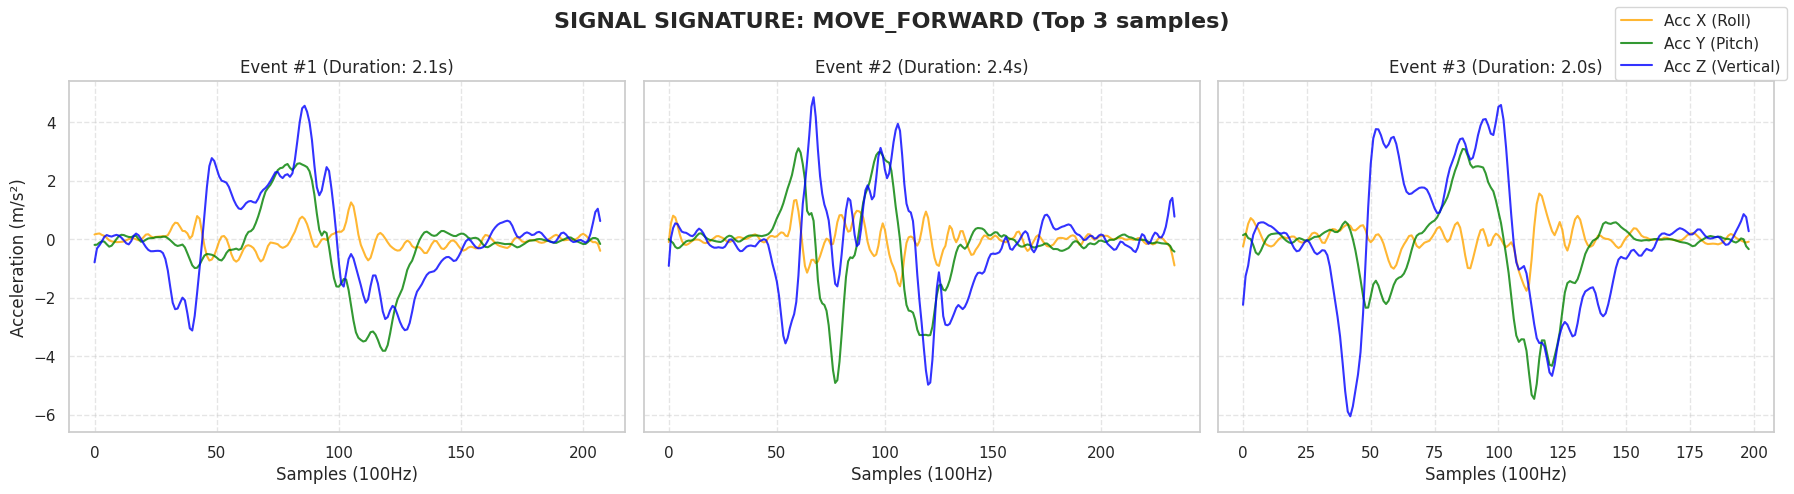

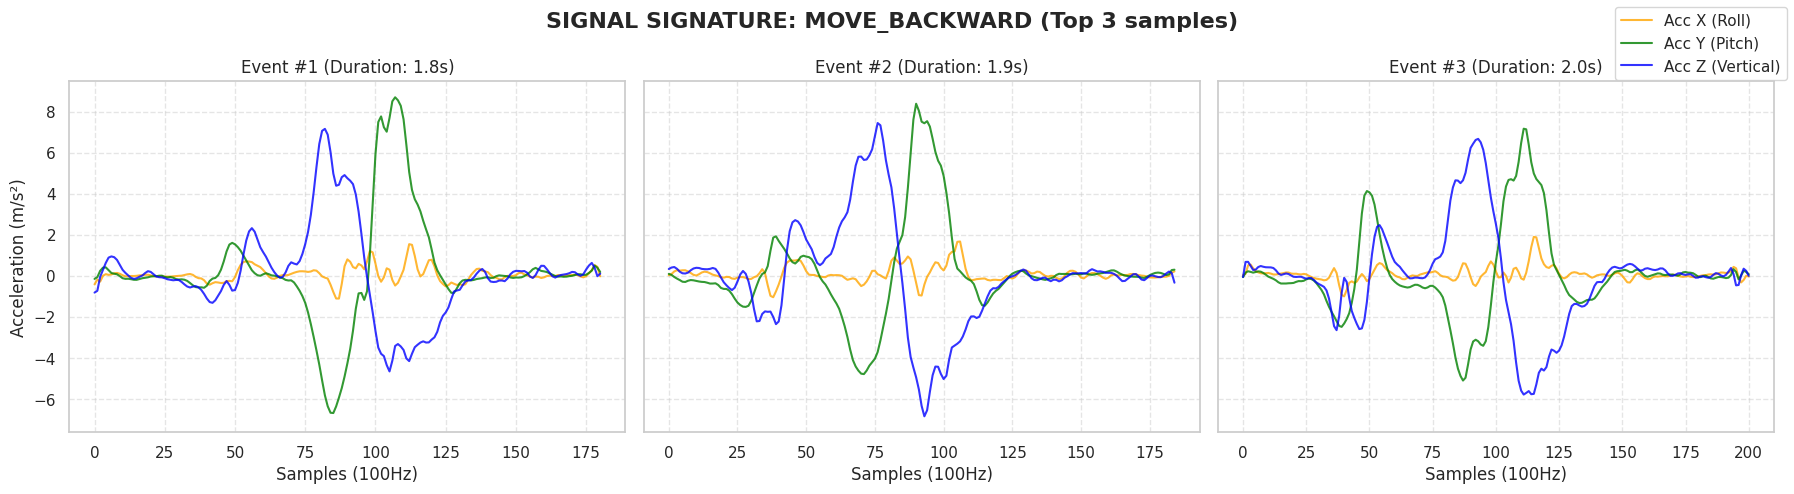

In [6]:
plot_class_signature(df, 'MOVE_FORWARD', n_samples=3)
plot_class_signature(df, 'MOVE_BACKWARD', n_samples=3)

### 🔍 KIỂM TRA NHÓM TĨNH & NHIỄU
- **IDLE:** Các đường phải thẳng tắp, sát 0 (trừ Z ~ 9.8).
- **HOVER:** Các đường dao động nhẹ quanh trục.
- **TURBULENCE:** Dao động mạnh, biên độ lớn (gai nhọn) liên tục.

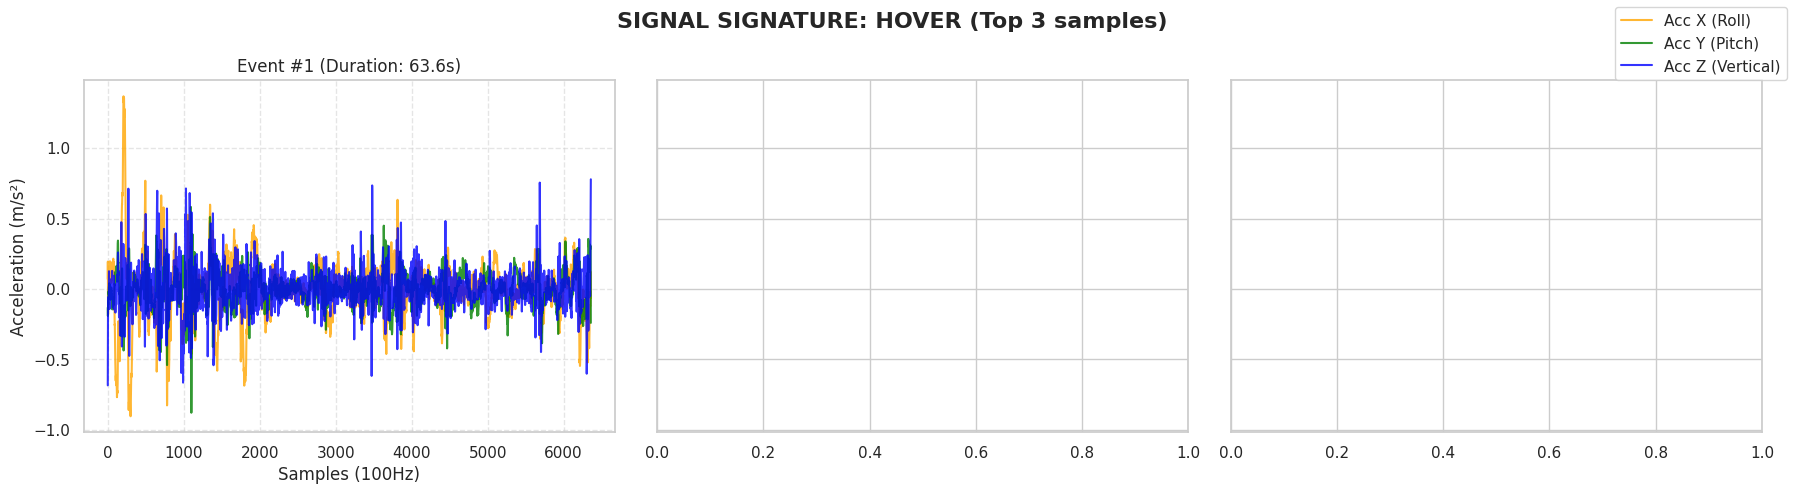

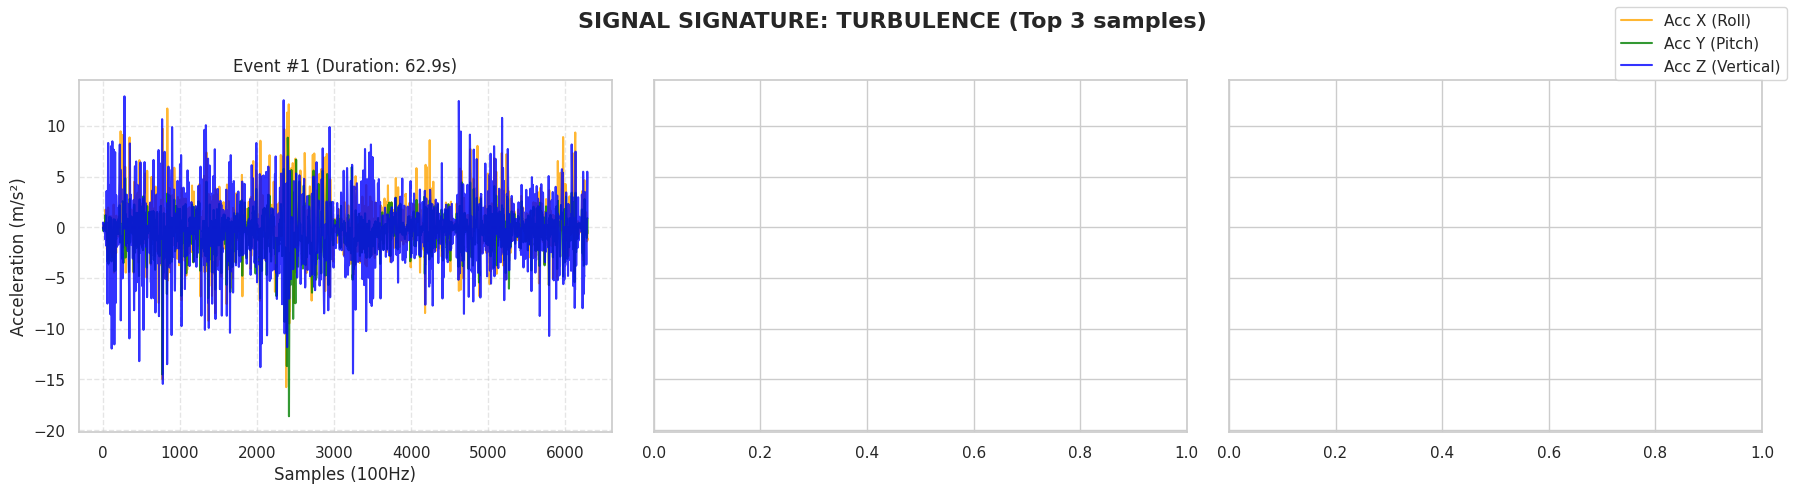

In [7]:
plot_class_signature(df, 'HOVER', n_samples=3)
plot_class_signature(df, 'TURBULENCE', n_samples=3)

## 🧠 3. PHÂN TÍCH NHANH (EXPERT INSIGHT)

Sau khi chạy các biểu đồ trên, hãy tự trả lời các câu hỏi này:
1. **Có mẫu nào bị "Lạc loài" không?** (Ví dụ: Đang là Left mà đường Acc_X lại phẳng lì -> Do quên nghiêng tay).
   - *Action:* Nếu có ít (<2 mẫu), có thể bỏ qua. Nếu nhiều, phải thu lại.
2. **Đoạn "Hold" có đủ dài không?**
   - Chiến thuật của chúng ta cần đoạn giữa phẳng (Plateau) ít nhất 1.0 giây (100 mẫu) để cửa sổ trượt bắt được.
3. **Tín hiệu "Nghiêng" có rõ không?**
   - Giá trị trung bình (Mean) khi nghiêng có khác biệt rõ rệt so với lúc Hover không? (Ví dụ: Hover X=0, Nghiêng X=5 -> Tốt).

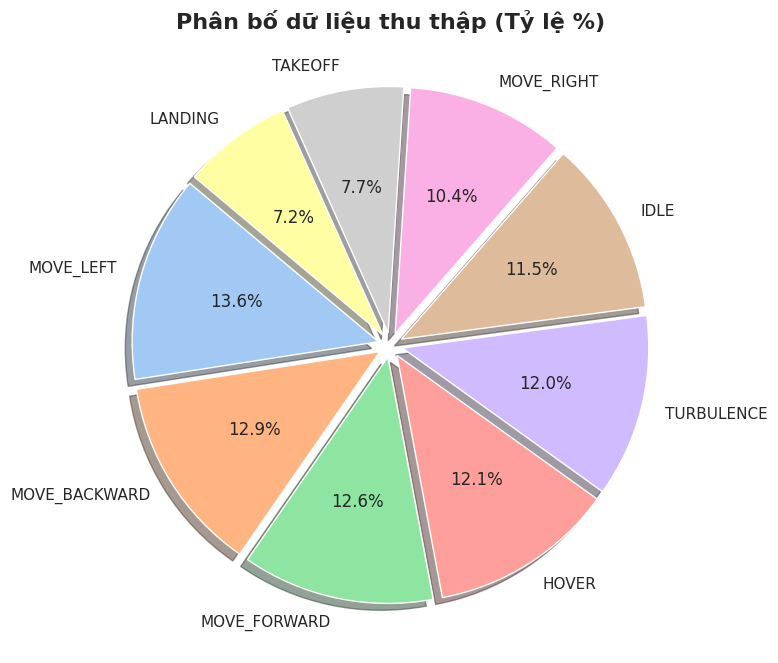

In [8]:
# --- VẼ PHÂN BỐ DỮ LIỆU (DATA DISTRIBUTION) ---
import matplotlib.pyplot as plt

def plot_data_distribution_pie(df):
    plt.figure(figsize=(8, 8))

    # Đếm số lượng mẫu
    counts = df['label'].value_counts()

    # Vẽ Pie Chart
    explode = [0.05] * len(counts) # Tách nhẹ các miếng bánh
    plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=140,
            explode=explode, shadow=True, colors=sns.color_palette("pastel"))

    plt.title("Phân bố dữ liệu thu thập (Tỷ lệ %)", fontsize=16, fontweight='bold')
    plt.show()

# Gọi hàm (Yêu cầu df đã load ở trên)
if 'df' in locals():
    plot_data_distribution_pie(df)
else:
    print("⚠️ Hãy chạy cell load dữ liệu trước!")

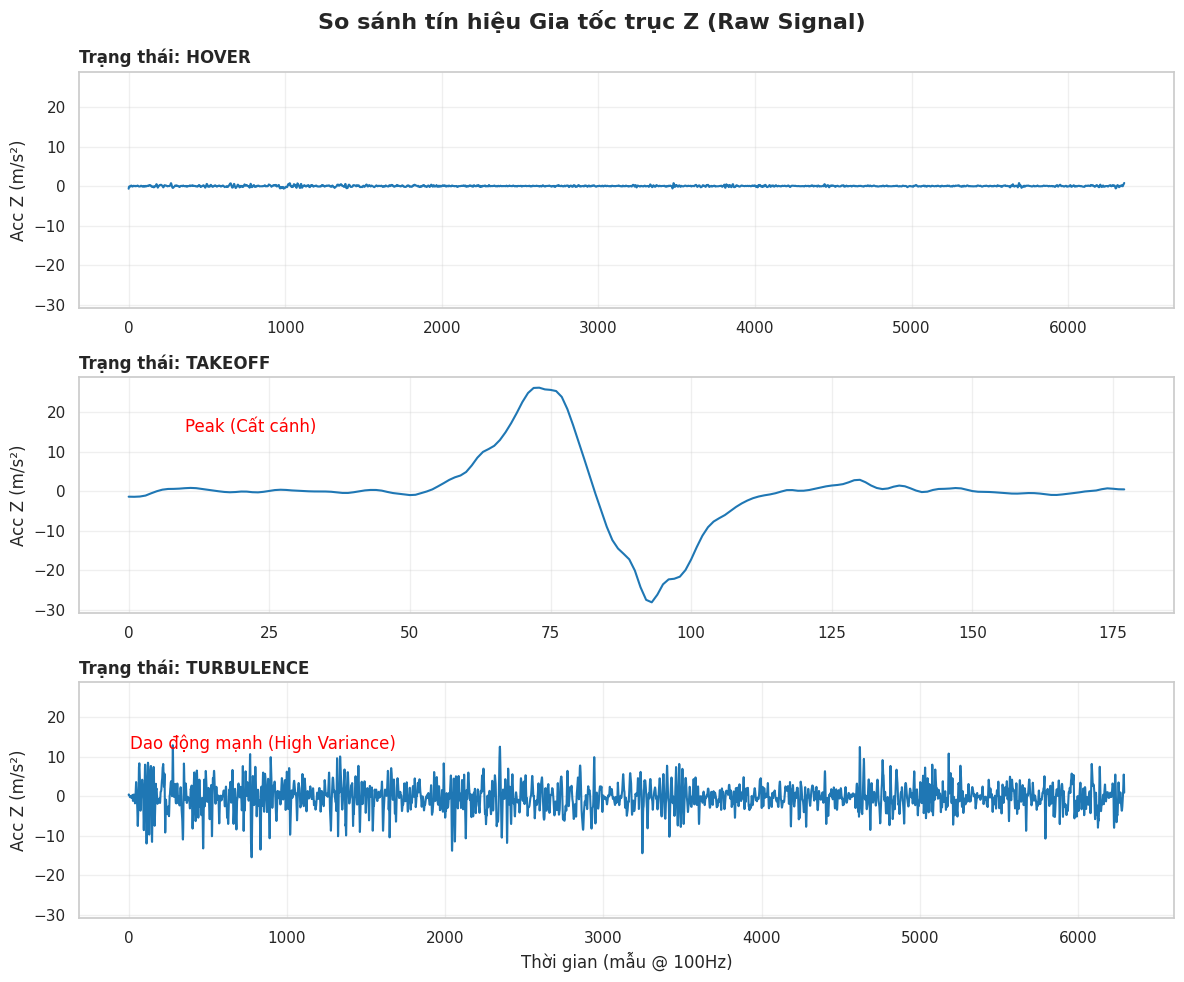

In [9]:
# --- VẼ SO SÁNH TÍN HIỆU (ACCELEROMETER Z) ---
def plot_signal_comparison(df):
    target_labels = ['HOVER', 'TAKEOFF', 'TURBULENCE']

    fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=False, sharey=True)
    fig.suptitle('So sánh tín hiệu Gia tốc trục Z (Raw Signal)', fontsize=16, fontweight='bold')

    for i, label in enumerate(target_labels):
        # Lấy 1 mẫu ngẫu nhiên của nhãn đó
        subset = df[df['label'] == label]
        if len(subset) > 0:
            seg_id = subset['segment_id'].unique()[0]
            data = subset[subset['segment_id'] == seg_id]

            # Vẽ
            axes[i].plot(data.reset_index(drop=True)['acc_z'], color='tab:blue', linewidth=1.5)
            axes[i].set_title(f"Trạng thái: {label}", fontsize=12, loc='left', fontweight='bold')
            axes[i].set_ylabel("Acc Z (m/s²)")
            axes[i].grid(True, alpha=0.3)

            # Highlight đặc điểm
            if label == 'TAKEOFF':
                axes[i].text(10, 15, "Peak (Cất cánh)", color='red')
            if label == 'TURBULENCE':
                axes[i].text(10, 12, "Dao động mạnh (High Variance)", color='red')

    plt.xlabel("Thời gian (mẫu @ 100Hz)")
    plt.tight_layout()
    plt.show()

if 'df' in locals(): plot_signal_comparison(df)

### 📈 4. VISUALIZATION: PHÂN BỐ THỜI LƯỢNG (SPLIT VIEW)
Để hiển thị rõ ràng cả các hành động ngắn và dài, chúng ta sẽ vẽ hai biểu đồ hộp (boxplot) riêng biệt.

/tmp/ipython-input-3681298763.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=seg_durations[seg_durations['label'].isin(short_duration_labels)],
/tmp/ipython-input-3681298763.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=seg_durations[seg_durations['label'].isin(long_duration_labels)],


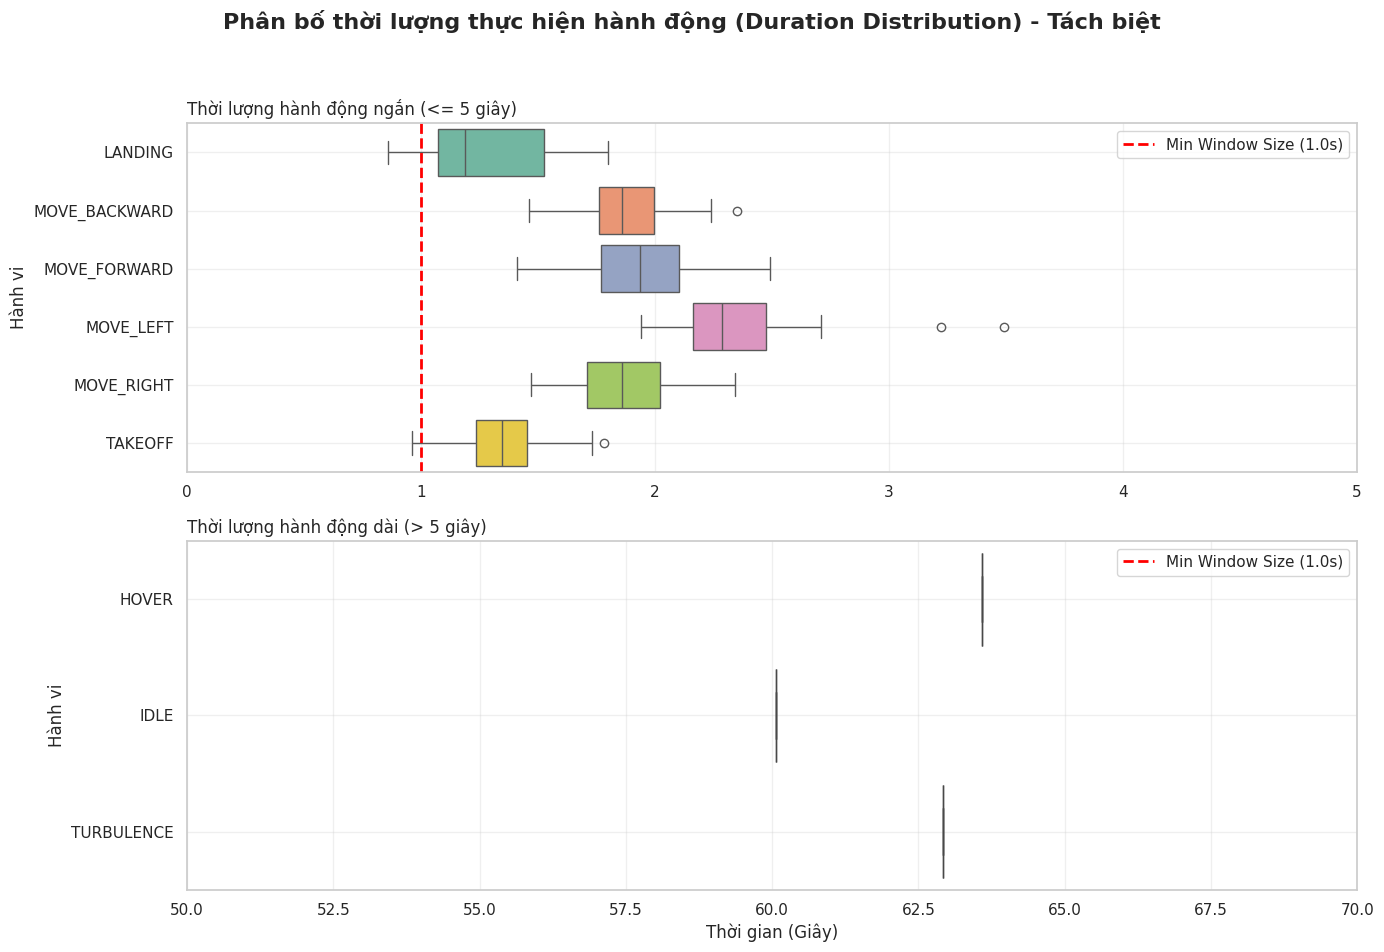


⏱️ THỐNG KÊ THỜI LƯỢNG (Giây):
                    mean    min    max
label                                 
HOVER          63.590000  63.59  63.59
IDLE           60.060000  60.06  60.06
LANDING         1.255667   0.86   1.80
MOVE_BACKWARD   1.877222   1.46   2.35
MOVE_FORWARD    1.938824   1.41   2.49
MOVE_LEFT       2.367000   1.94   3.49
MOVE_RIGHT      1.880345   1.47   2.34
TAKEOFF         1.344667   0.96   1.78
TURBULENCE     62.920000  62.92  62.92


In [10]:
# ==============================================================================
# ⏱️ CHART 1.1 & 1.2: PHÂN TÍCH THỜI LƯỢNG MẪU (SPLIT DURATION DISTRIBUTION)
# ==============================================================================
def plot_duration_distribution_split(df):
    # 1. Tính thời lượng cho từng segment
    seg_durations = df.groupby(['label', 'segment_id']).size().reset_index(name='count')
    seg_durations['duration_sec'] = seg_durations['count'] / 100.0 # fs=100

    # Phân loại các nhãn thành nhóm 'ngắn' và 'dài'
    short_duration_labels = seg_durations[seg_durations['duration_sec'] <= 5]['label'].unique()
    long_duration_labels = seg_durations[seg_durations['duration_sec'] > 5]['label'].unique()

    fig, axs = plt.subplots(2, 1, figsize=(14, 10), sharex=False) # 2 hàng, 1 cột
    fig.suptitle('Phân bố thời lượng thực hiện hành động (Duration Distribution) - Tách biệt', fontsize=16, fontweight='bold')

    # --- Subplot 1: Hành động ngắn ---
    if not seg_durations[seg_durations['label'].isin(short_duration_labels)].empty:
        sns.boxplot(data=seg_durations[seg_durations['label'].isin(short_duration_labels)],
                    x='duration_sec', y='label', palette='Set2', showfliers=True, ax=axs[0])
        axs[0].set_title('Thời lượng hành động ngắn (<= 5 giây)', loc='left')
        axs[0].set_xlabel('') # Loại bỏ nhãn x để tránh trùng với subplot dưới
        axs[0].set_ylabel('Hành vi')
        axs[0].axvline(x=1.0, color='red', linestyle='--', linewidth=2, label='Min Window Size (1.0s)')
        axs[0].set_xlim(0, 5) # Giới hạn rõ ràng cho nhóm ngắn
        axs[0].legend()
        axs[0].grid(True, alpha=0.3)
    else:
        axs[0].set_visible(False) # Ẩn subplot nếu không có dữ liệu

    # --- Subplot 2: Hành động dài ---
    if not seg_durations[seg_durations['label'].isin(long_duration_labels)].empty:
        sns.boxplot(data=seg_durations[seg_durations['label'].isin(long_duration_labels)],
                    x='duration_sec', y='label', palette='Set1', showfliers=True, ax=axs[1])
        axs[1].set_title('Thời lượng hành động dài (> 5 giây)', loc='left')
        axs[1].set_xlabel('Thời gian (Giây)')
        axs[1].set_ylabel('Hành vi')
        axs[1].axvline(x=1.0, color='red', linestyle='--', linewidth=2, label='Min Window Size (1.0s)')
        # Giới hạn x từ 50 đến 70 để bao quát các hành động 60s
        axs[1].set_xlim(50, 70)
        axs[1].legend()
        axs[1].grid(True, alpha=0.3)
    else:
        axs[1].set_visible(False) # Ẩn subplot nếu không có dữ liệu

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Điều chỉnh layout để tránh chồng chéo tiêu đề chính
    plt.show()

    # In thống kê ngắn gọn (vẫn như cũ)
    print("\n⏱️ THỐNG KÊ THỜI LƯỢNG (Giây):")
    print(seg_durations.groupby('label')['duration_sec'].describe()[['mean', 'min', 'max']])

if 'df' in locals():
    plot_duration_distribution_split(df)


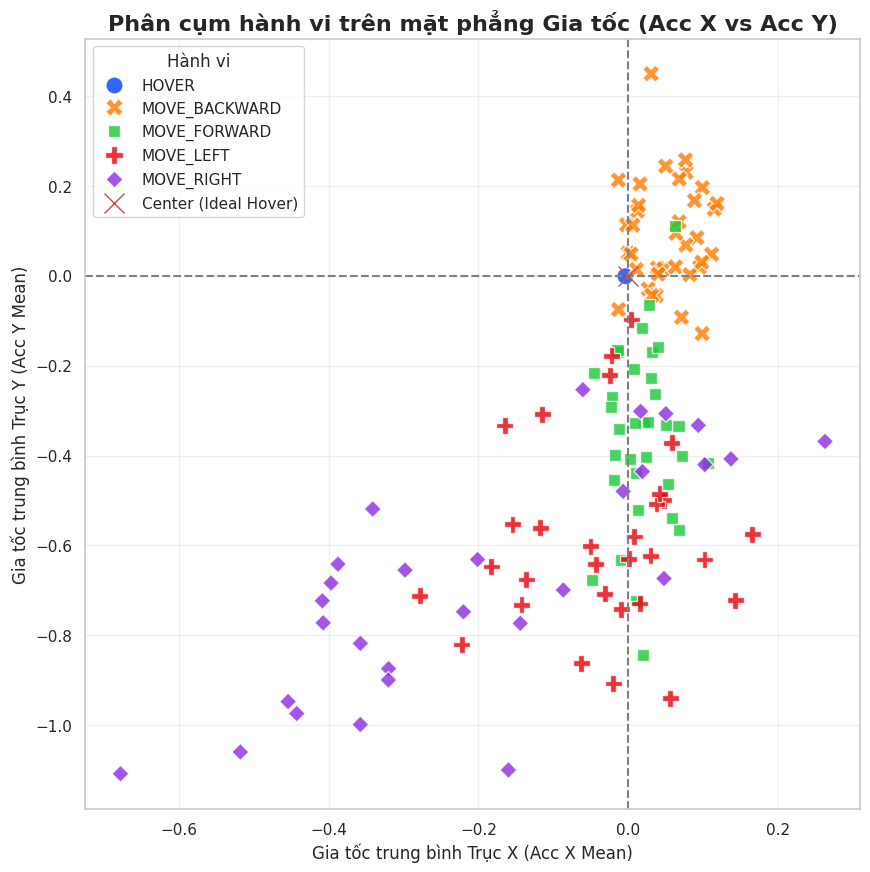

In [11]:
# ==============================================================================
# 🧭 CHART 2: PHÂN CỤM ĐIỀU HƯỚNG (NAVIGATION CLUSTERS)
# ==============================================================================
def plot_maneuver_clusters(df):
    # Chỉ lấy các nhãn di chuyển và Hover
    target_labels = ['HOVER', 'MOVE_LEFT', 'MOVE_RIGHT', 'MOVE_FORWARD', 'MOVE_BACKWARD']
    subset = df[df['label'].isin(target_labels)].copy()

    # Tính trung bình Acc X và Acc Y cho mỗi segment (Mỗi lần nhấn nút là 1 điểm trên đồ thị)
    # Ý nghĩa: Nghiêng trái thì Acc X trung bình sẽ lệch dương/âm, Hover thì về 0
    cluster_data = subset.groupby(['label', 'segment_id'])[['acc_x', 'acc_y']].mean().reset_index()

    plt.figure(figsize=(10, 10))
    sns.scatterplot(data=cluster_data, x='acc_x', y='acc_y', hue='label',
                    style='label', s=150, palette='bright', alpha=0.8)

    # Vẽ tâm (0,0) - Vị trí Hover lý tưởng
    plt.axhline(0, color='gray', linestyle='--')
    plt.axvline(0, color='gray', linestyle='--')
    plt.plot(0, 0, 'rx', markersize=15, label='Center (Ideal Hover)')

    plt.title('Phân cụm hành vi trên mặt phẳng Gia tốc (Acc X vs Acc Y)', fontsize=16, fontweight='bold')
    plt.xlabel('Gia tốc trung bình Trục X (Acc X Mean)')
    plt.ylabel('Gia tốc trung bình Trục Y (Acc Y Mean)')
    plt.legend(title='Hành vi')
    plt.grid(True, alpha=0.3)
    plt.show()

if 'df' in locals():
    plot_maneuver_clusters(df)

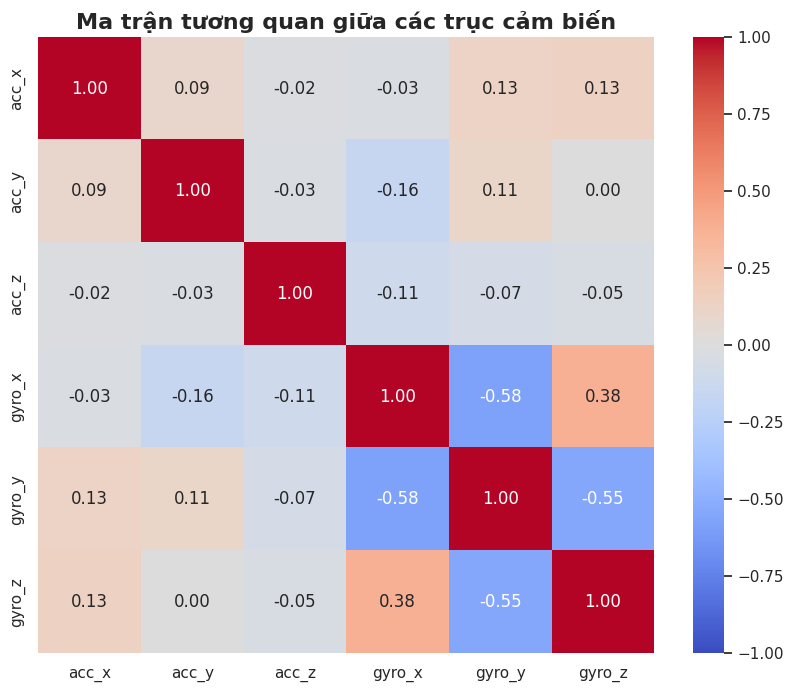

In [12]:
# ==============================================================================
# 🔥 CHART 3: MA TRẬN TƯƠNG QUAN CẢM BIẾN (SENSOR CORRELATION)
# ==============================================================================
def plot_sensor_correlation(df):
    # Chỉ lấy các cột cảm biến
    sensor_cols = ['acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z']
    corr_matrix = df[sensor_cols].corr()

    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, square=True)

    plt.title('Ma trận tương quan giữa các trục cảm biến', fontsize=16, fontweight='bold')
    plt.show()

if 'df' in locals():
    plot_sensor_correlation(df)

In [14]:
# ==============================================================================
# 👀 QUICK VIEW: 5 DÒNG ĐẦU TIÊN CỦA DỮ LIỆU
# ==============================================================================
if 'df' in locals():
    print("📄 5 dòng đầu tiên của train_raw_clean.csv:\n")
    display(df.head(5))
else:
    print("⚠️ DataFrame df chưa được load!")


📄 5 dòng đầu tiên của train_raw_clean.csv:



,time,acc_x,acc_y,acc_z,gyro_x,gyro_y,gyro_z,label,segment_id
0,2025-12-24 17:07:00.493467600,-0.042938,0.006239,0.181601,-0.175902,-0.037018,-0.168178,MOVE_LEFT,0
1,2025-12-24 17:07:00.503489500,-0.078719,0.084050,0.427190,-0.131161,0.001332,-0.146873,MOVE_LEFT,0
2,2025-12-24 17:07:00.513517000,-0.097845,0.144557,0.513736,-0.060853,0.023702,-0.120242,MOVE_LEFT,0
3,2025-12-24 17:07:00.523531800,-0.096203,0.150070,0.406246,0.012650,0.042877,-0.090414,MOVE_LEFT,0
4,2025-12-24 17:07:00.533547000,-0.110465,0.121850,0.216105,0.070174,0.075900,-0.062717,MOVE_LEFT,0
